Below is: Most common political keywords, Most common keywords within 4 distinct categories, the count of the same keywords as the news analysis notebook, then visualizations of the most common political keywords at the end


In [31]:
import os
print(os.getcwd())


/Users/ailiebalke/Documents/GitHub/Media-Politics/project


In [4]:
import os
import pandas as pd

os.chdir('/Users/ailiebalke/Documents/GitHub/Media-Politics/project')

speeches_df = pd.read_csv('data/clean/japan_speeches_cleaned.csv', index_col="date", parse_dates=True)
speeches_df.tail()

,title,source,text
date,,,
2021-12-08,Opening Speech by Prime Minister KISHIDA Fumio...,Prime Minister of Japan and His Cabinet,"I am KISHIDA Fumio, Prime Minister of Japan. I..."
2021-12-09,Video Message by Prime Minister KISHIDA Fumio ...,Prime Minister of Japan and His Cabinet,"Ladies and gentlemen,\n\nMy administration att..."
2021-12-14,Video Message by Prime Minister KISHIDA Fumio ...,Prime Minister of Japan and His Cabinet,"Excellencies, distinguished guests, dear colle..."
2021-12-21,Video Message by Prime Minister KISHIDA Fumio ...,Prime Minister of Japan and His Cabinet,"I am KISHIDA Fumio, Prime Minister of Japan. I..."
2021-12-22,Video Message by Prime Minister KISHIDA Fumio ...,Prime Minister of Japan and His Cabinet,"Distinguished guests, I am KISHIDA Fumio, Prim..."


/var/folders/rs/cvl482l132x4zmlr9gy65r5m0000gn/T/ipykernel_22016/3013572604.py:24: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  matches = df[df["text"].str.contains(pattern, case=False, na=False, regex=True)]
/var/folders/rs/cvl482l132x4zmlr9gy65r5m0000gn/T/ipykernel_22016/3013572604.py:24: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  matches = df[df["text"].str.contains(pattern, case=False, na=False, regex=True)]
/var/folders/rs/cvl482l132x4zmlr9gy65r5m0000gn/T/ipykernel_22016/3013572604.py:24: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  matches = df[df["text"].str.contains(pattern, case=False, na=False, regex=True)]
/var/folders/rs/cvl482l132x4zmlr9gy65r5m0000gn/T/ipykernel_22016/3013572604.py:24: UserWarning: This pa

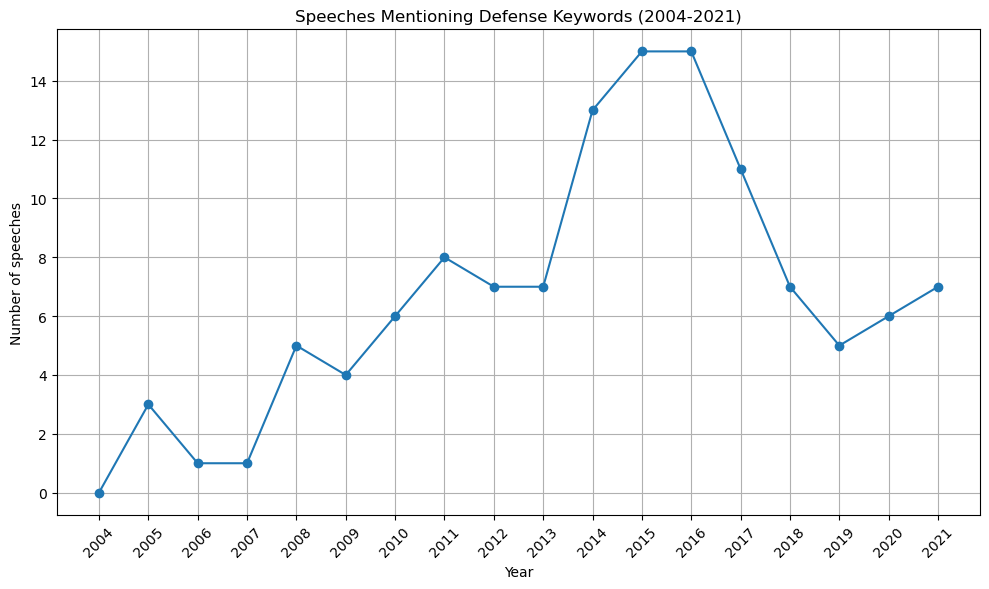

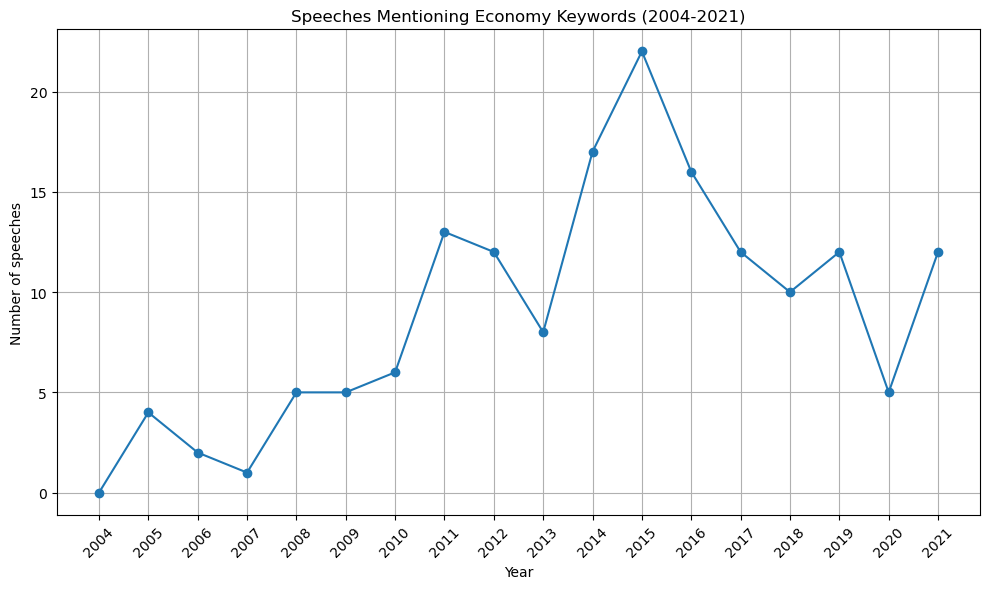

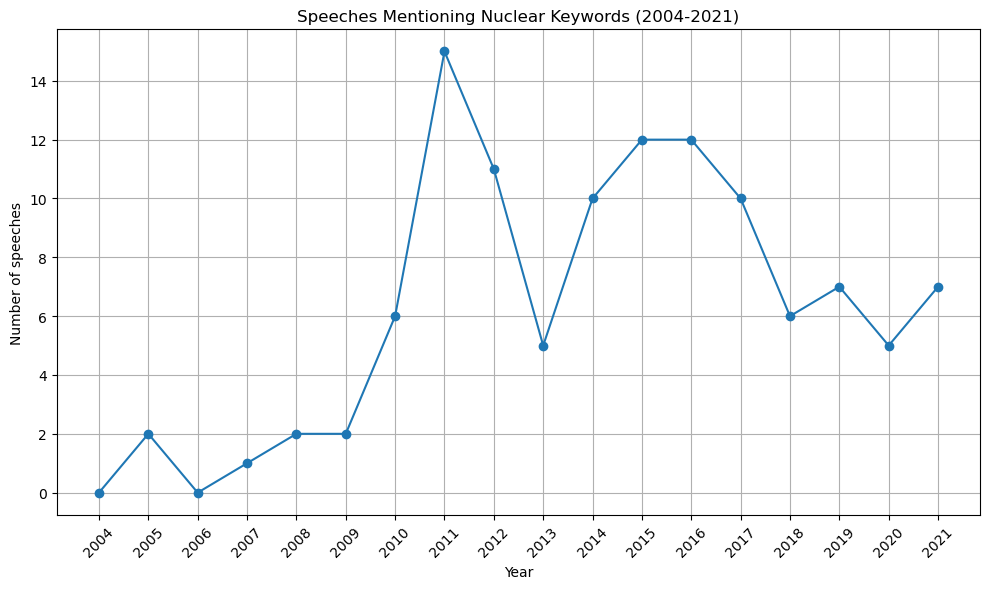

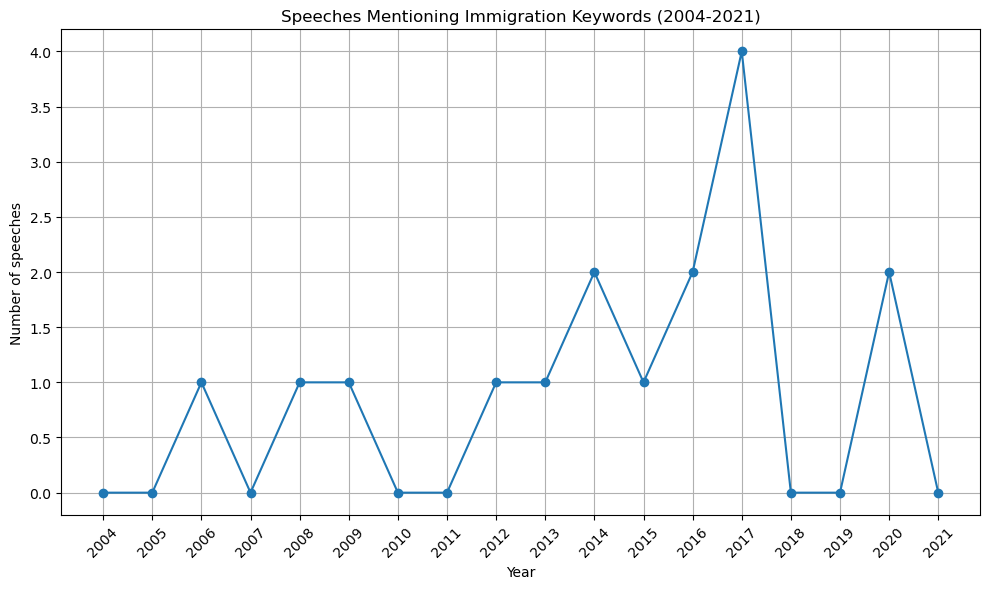

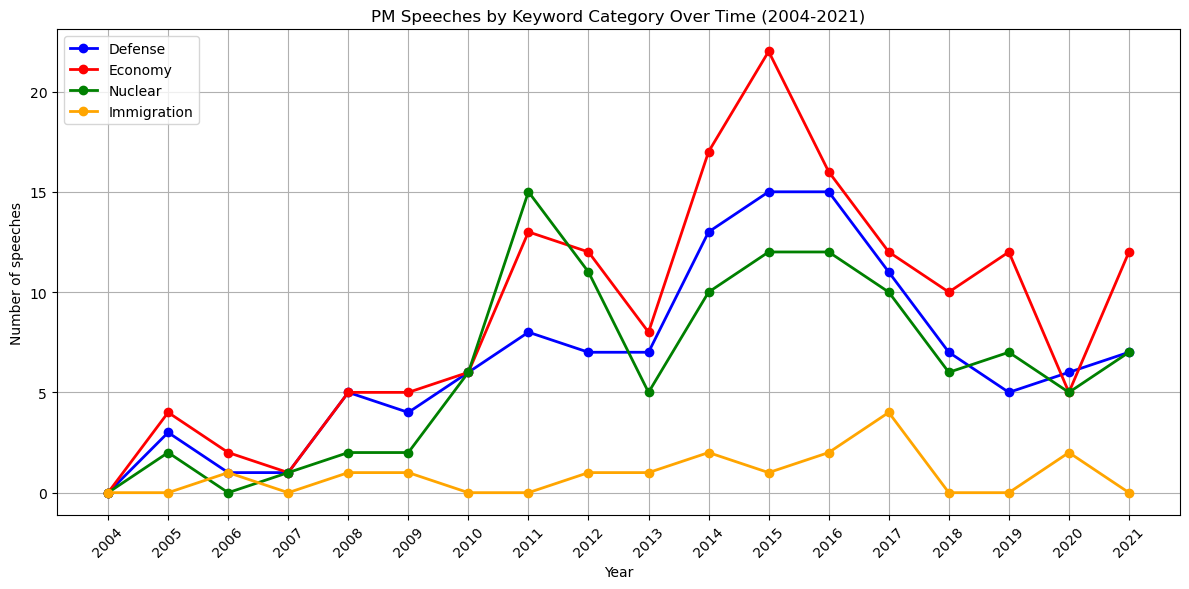

In [5]:
import re
import matplotlib.pyplot as plt
import pandas as pd
import sys

sys.path.append("..")

from src.keywords import CATEGORY_KEYWORDS


YEAR_START, YEAR_END = 2004, 2021
COLORS = ["blue", "red", "green", "orange"]

speeches_2004_2021 = speeches_df[
    (speeches_df.index.year >= YEAR_START) & (speeches_df.index.year <= YEAR_END)
]

category_patterns = {
    category: r"\b(" + "|".join(re.escape(kw) for kw in keywords) + r")\b"
    for category, keywords in CATEGORY_KEYWORDS.items()
}

def category_speech_counts(pattern, df):
    matches = df[df["text"].str.contains(pattern, case=False, na=False, regex=True)]
    counts = matches.resample("YE").size()
    return counts.reindex(
        pd.date_range(f"{YEAR_START}-01-01", f"{YEAR_END}-12-31", freq="YE"), fill_value=0
    )

category_year_counts = {
    category: category_speech_counts(pattern, speeches_2004_2021)
    for category, pattern in category_patterns.items()
}

# Individual trend chart per category
for category, counts in category_year_counts.items():
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(counts.index.year, counts.values, marker="o")
    ax.set_xlabel("Year")
    ax.set_ylabel("Number of speeches")
    ax.set_title(f"Speeches Mentioning {category.capitalize()} Keywords ({YEAR_START}-{YEAR_END})")
    ax.set_xticks(range(YEAR_START, YEAR_END + 1))
    ax.tick_params(axis="x", rotation=45)
    ax.grid(True)
    plt.tight_layout()
    plt.show()

# Combined trend chart, all categories together
fig, ax = plt.subplots(figsize=(12, 6))
for (category, counts), color in zip(category_year_counts.items(), COLORS):
    ax.plot(counts.index.year, counts.values, label=category.capitalize(), color=color, marker="o", linewidth=2)

ax.set_xlabel("Year")
ax.set_ylabel("Number of speeches")
ax.set_title(f"PM Speeches by Keyword Category Over Time ({YEAR_START}-{YEAR_END})")
ax.set_xticks(range(YEAR_START, YEAR_END + 1))
ax.tick_params(axis="x", rotation=45)
ax.legend(loc="upper left")
ax.grid(True)
plt.tight_layout()
plt.show()


In [35]:
import sys
import re
import pandas as pd

sys.path.append("notebooks")
from keywords import CATEGORY_KEYWORDS

category_patterns = {
    category: r"\b(" + "|".join(re.escape(kw) for kw in keywords) + r")\b"
    for category, keywords in CATEGORY_KEYWORDS.items()
}

category_matches = {}
for category, pattern in category_patterns.items():
    matches = speeches_df[speeches_df["text"].str.contains(pattern, case=False, na=False, regex=True)]
    category_matches[category] = matches
    print(f"{category}: {len(matches)} speeches mention this category's keywords")

# Example: look at the speeches matched for one category
category_matches["defense"][["title", "place"]].head()


/var/folders/rs/cvl482l132x4zmlr9gy65r5m0000gn/T/ipykernel_79068/434219010.py:15: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  matches = speeches_df[speeches_df["text"].str.contains(pattern, case=False, na=False, regex=True)]


defense: 350 speeches mention this category's keywords
economy: 348 speeches mention this category's keywords
nuclear: 196 speeches mention this category's keywords
immigration: 36 speeches mention this category's keywords
nationalist: 82 speeches mention this category's keywords


,title,place
date,,
1951-09-07,Prime Minister Shigeru Yoshida's Speech at the...,San Francisco
1977-08-18,SPEECH BY PRIME MINISTER TAKEO FUKUDA (Fukuda ...,Manila
1988-05-04,Statement by Prime Minister Takeshita on the O...,London
1991-05-03,Policy Speech by Prime Minister Toshiki Kaifu ...,Singapore
1991-05-27,Address by Prime Minister Toshiki Kaifu at the...,"Kyoto, Japan"


Just top keywords for speeches: 

In [19]:
import spacy
from collections import Counter, defaultdict
import pandas as pd

import sys
sys.path.append("notebooks")
from keywords import CATEGORY_KEYWORDS  # defense, economy, nuclear, immigration 

YEAR_START, YEAR_END = 2004, 2021
TARGET_POS = {"NOUN", "PROPN", "ADJ"}
GLUE_WORDS = {"of", "the", "this", "these", "those", "our", "their", "his", "her"}
GENERIC_NOUNS = {
    "number", "amount", "kind", "type", "part", "lot", "rest", "use",
    "case", "way", "fact", "thing", "point", "matter", "issue", "term",
}
MIN_DOC_FREQ = 2

nlp = spacy.load("en_core_web_sm")
ALL_POLITICAL_KEYWORDS = set().union(*CATEGORY_KEYWORDS.values())

speeches_range = speeches_df[
    (speeches_df.index.year >= YEAR_START) & (speeches_df.index.year <= YEAR_END)
]

def extract_phrases(text):
    doc = nlp(str(text))
    tokens = [t for t in doc if not t.is_space and not t.is_punct]
    phrases = []
    i = 0
    while i < len(tokens):
        phrase_tokens = []
        j = i
        while j < len(tokens) and (
            tokens[j].pos_ in TARGET_POS
            or (tokens[j].text.lower() in GLUE_WORDS and phrase_tokens)
        ):
            phrase_tokens.append(tokens[j].text)
            j += 1

        # drop trailing glue words so phrases don't end mid-thought (e.g. "use of")
        while phrase_tokens and phrase_tokens[-1].lower() in GLUE_WORDS:
            phrase_tokens.pop()
            j -= 1

        if (
            len(phrase_tokens) >= 2
            and phrase_tokens[0].lower() not in GENERIC_NOUNS
            and phrase_tokens[-1].lower() not in GENERIC_NOUNS
        ):
            phrases.append(" ".join(phrase_tokens).lower())

        i = j if j > i else i + 1
    return phrases

def is_political(phrase):
    return any(keyword in phrase for keyword in ALL_POLITICAL_KEYWORDS)

def matched_categories(phrase):
    return [cat for cat, kws in CATEGORY_KEYWORDS.items() if any(kw in phrase for kw in kws)]

phrase_counts = Counter()
phrase_doc_ids = defaultdict(set)

for date, row in speeches_range.iterrows():
    for phrase in extract_phrases(row["text"]):
        if not is_political(phrase):
            continue
        phrase_counts[phrase] += 1
        phrase_doc_ids[phrase].add(date)

rows = [
    {
        "phrase": phrase,
        "categories": ", ".join(matched_categories(phrase)),
        "total_count": count,
        "doc_freq": len(phrase_doc_ids[phrase]),
    }
    for phrase, count in phrase_counts.items()
    if len(phrase_doc_ids[phrase]) >= MIN_DOC_FREQ
]

top_political_phrases_df = pd.DataFrame(rows).sort_values("total_count", ascending=False).head(100).reset_index(drop=True)
top_political_phrases_df


,phrase,categories,total_count,doc_freq
0,nuclear weapons,nuclear,65,26
1,world free of nuclear weapons,nuclear,45,17
2,atomic bomb survivors,nuclear,41,21
3,economic growth,economy,40,26
4,nuclear disarmament,nuclear,27,19
...,...,...,...,...
95,sake of the ultimate elimination of nuclear we...,nuclear,4,4
96,financial contributions,economy,4,2
97,fruits of growth,economy,4,4
98,serious threat,defense,4,4


world cloud, bar chart, and graph of frequency of top 10 keywords 

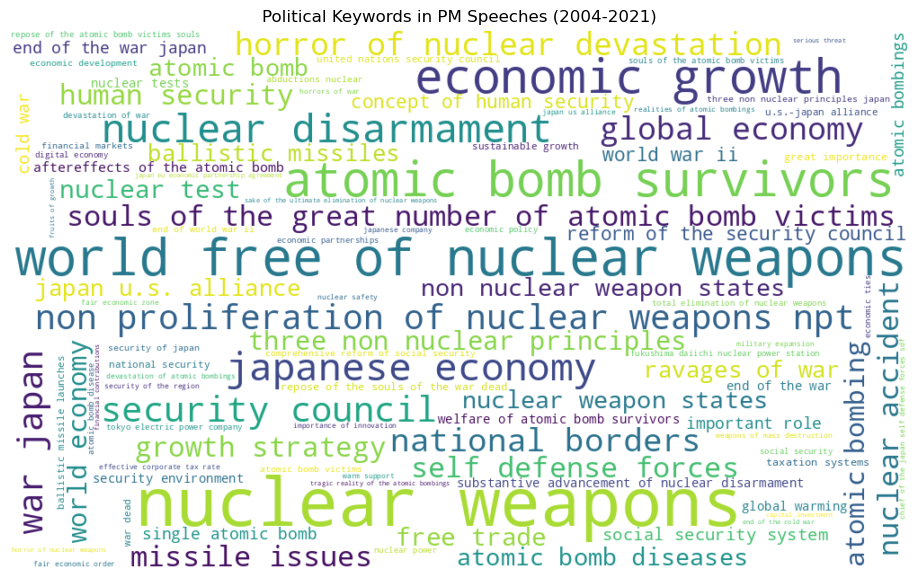

In [20]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

phrase_frequencies = dict(zip(top_political_phrases_df["phrase"], top_political_phrases_df["total_count"]))

political_wordcloud = WordCloud(
    width=1000, height=600, background_color="white"
).generate_from_frequencies(phrase_frequencies)

plt.figure(figsize=(12, 7))
plt.imshow(political_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title(f"Political Keywords in PM Speeches ({YEAR_START}-{YEAR_END})")
plt.show()


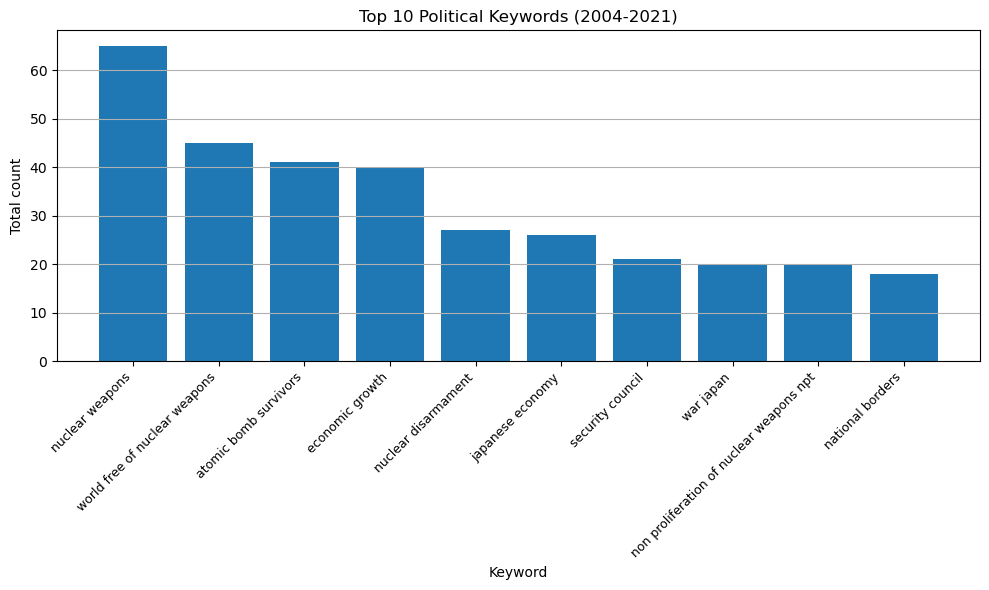

In [21]:
import matplotlib.pyplot as plt

top_10_phrases_df = top_political_phrases_df.head(10)

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(top_10_phrases_df["phrase"], top_10_phrases_df["total_count"])

ax.set_xlabel("Keyword")
ax.set_ylabel("Total count")
ax.set_title(f"Top 10 Political Keywords ({YEAR_START}-{YEAR_END})")
ax.tick_params(axis="x", rotation=45, labelsize=9)
for label in ax.get_xticklabels():
    label.set_horizontalalignment("right")
ax.grid(True, axis="y")
plt.tight_layout()
plt.show()
